# Phase 1a — Upgrade: Feature Engineering

## Apa yang kita upgrade dan kenapa?

Di kode kamu sekarang, model LSTM hanya 'melihat' satu hal: **closing price** kemarin, kemarin lusa, dan 58 hari sebelumnya.

Bayangkan kamu mau nebak apakah besok akan hujan. Kalau kamu cuma lihat suhu kemarin, tebakan kamu pasti kurang akurat. Tapi kalau kamu juga lihat kelembapan, kecepatan angin, dan tekanan udara — tebakan kamu jadi jauh lebih baik.

Itulah yang kita lakukan di sini. Kita tambahkan **technical indicators** sebagai 'indra' baru untuk model:

| Indikator | Analogi | Yang diukur |
|-----------|---------|-------------|
| **RSI** | Termometer momentum | Apakah saham terlalu overbought atau oversold? |
| **MACD** | Kompas tren | Ke mana arah momentum sekarang? |
| **Bollinger Bands** | Selimut volatilitas | Seberapa 'liar' pergerakan harga? |
| **Volume** | Keyakinan pasar | Seberapa banyak orang yang trading? |

## Cara pakai notebook ini

Tambahkan cells ini **setelah** cell download data kamu (`pred_df = yf.download(...)`) dan **gantikan** semua bagian LSTM ke bawah.

Kode kamu yang lama tidak dihapus — justru kita jadikan baseline untuk dibandingkan.

---
## Bagian 0 — Install library baru

Kita butuh satu library tambahan: `pandas-ta` untuk menghitung technical indicators.
Jalankan cell ini sekali saja, lalu restart kernel kalau diminta.

In [1]:
# Jalankan sekali, lalu TIDAK perlu dijalankan lagi
# !pip install ta

---
## Bagian 1 — Download data (sama seperti kode kamu)

Ini persis sama dengan kode kamu. Kita copy di sini supaya notebook ini bisa jalan sendiri.

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ta  # pip install ta — support Python 3.10
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# --- Sama persis dengan kode kamu ---
start = datetime(2023, 8, 28)
end   = datetime(2025, 8, 28)

# Download data AAPL (persis seperti pred_df kamu)
pred_df = yf.download('AAPL', start, end=end, auto_adjust=False)

print(f'Data AAPL berhasil didownload.')
print(f'Jumlah hari trading: {len(pred_df)}')
print(f'Dari {pred_df.index[0].date()} sampai {pred_df.index[-1].date()}')
pred_df.tail(3)

[*********************100%***********************]  1 of 1 completed

Data AAPL berhasil didownload.
Jumlah hari trading: 502
Dari 2023-08-28 sampai 2025-08-27


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2025-08-25,226.519165,227.160004,229.300003,226.229996,226.479996,30983100
2025-08-26,228.663086,229.309998,229.490005,224.690002,226.869995,54575100
2025-08-27,229.839767,230.490005,230.899994,228.259995,228.610001,31259500


---
## Bagian 2 — Tambahkan technical indicators

Di sini kita mulai upgradenya. Kode kamu sebelumnya langsung ambil kolom `Close` saja:
```python
# kode lama kamu
pred_dfs = pred_df['Close']['AAPL'].to_frame()  # hanya 1 kolom
```

Sekarang kita buat DataFrame baru yang berisi Close + semua indikator tambahan.

In [3]:
# Ambil kolom yang kita butuhkan dari pred_df
# pred_df punya MultiIndex columns: ('Close', 'AAPL'), ('High', 'AAPL'), dst
aapl = pd.DataFrame()
aapl['Close']  = pred_df['Close']['AAPL']
aapl['High']   = pred_df['High']['AAPL']
aapl['Low']    = pred_df['Low']['AAPL']
aapl['Open']   = pred_df['Open']['AAPL']
aapl['Volume'] = pred_df['Volume']['AAPL']

# ============================================================
# HITUNG TECHNICAL INDICATORS
# ============================================================

# --- RSI (Relative Strength Index) ---
# Range: 0 sampai 100
# RSI > 70 = overbought → harga mungkin akan turun (terlalu banyak yang beli)
# RSI < 30 = oversold  → harga mungkin akan naik (terlalu banyak yang jual)
# Period 14 hari = standar yang paling umum dipakai
aapl['RSI'] = ta.momentum.RSIIndicator(aapl['Close'], window=14).rsi()

# --- MACD (Moving Average Convergence Divergence) ---
# Cara kerjanya: hitung dua moving average dengan kecepatan berbeda,
# lalu lihat selisihnya. Kalau MACD line melintasi signal line ke atas
# = sinyal bullish (harga cenderung naik)
# Parameter standar: fast=12 hari, slow=26 hari, signal=9 hari
macd_obj = ta.trend.MACD(aapl['Close'], window_fast=12, window_slow=26, window_sign=9)
aapl['MACD']        = macd_obj.macd()          # garis MACD utama
aapl['MACD_Signal'] = macd_obj.macd_signal()   # garis signal
aapl['MACD_Hist']   = macd_obj.macd_diff()     # histogram (selisih keduanya)

# --- Bollinger Bands ---
# Tiga garis: upper, middle (SMA 20 hari), lower
# Semakin lebar bandnya = semakin volatile harganya
# Kalau harga menyentuh upper band = overbought
# Kalau harga menyentuh lower band = oversold
bb_obj = ta.volatility.BollingerBands(aapl['Close'], window=20, window_dev=2)
aapl['BB_Upper']  = bb_obj.bollinger_hband()
aapl['BB_Middle'] = bb_obj.bollinger_mavg()
aapl['BB_Lower']  = bb_obj.bollinger_lband()
aapl['BB_Width']  = (aapl['BB_Upper'] - aapl['BB_Lower']) / aapl['BB_Middle']
# BB_Width = seberapa lebar band → ukuran volatilitas

# --- Simple Moving Averages ---
# Ini yang sudah kamu hitung sebelumnya (MA for 10/20/50 days)
# Kita tambahkan SMA 20 dan 50 sebagai fitur model
aapl['SMA_20'] = ta.trend.SMAIndicator(aapl['Close'], window=20).sma_indicator()
aapl['SMA_50'] = ta.trend.SMAIndicator(aapl['Close'], window=50).sma_indicator()

# --- Volume Ratio ---
# Volume hari ini dibagi rata-rata volume 20 hari
# Kalau > 1 = volume di atas rata-rata = tren lebih kuat
# Kalau < 1 = volume rendah = pergerakan harga kurang meyakinkan
aapl['Volume_Ratio'] = aapl['Volume'] / aapl['Volume'].rolling(20).mean()

# --- Daily Return ---
# Persentase perubahan harga hari ini vs kemarin
# Contoh: kalau Close kemarin 200, hari ini 204 → Daily Return = 2%
aapl['Daily_Return'] = aapl['Close'].pct_change()

# Hapus baris awal yang NaN
# SMA_50 butuh 50 baris pertama untuk dihitung, jadi 50 baris awal akan NaN
# dropna() bersihkan semuanya sekaligus
aapl.dropna(inplace=True)

print(f'Jumlah fitur yang tersedia: {len(aapl.columns)}')
print(f'Kolom-kolomnya:')
for col in aapl.columns:
    print(f'  - {col}')
print(f'\nJumlah hari data (setelah dropna): {len(aapl)}')
aapl.tail(3)

Jumlah fitur yang tersedia: 17
Kolom-kolomnya:
  - Close
  - High
  - Low
  - Open
  - Volume
  - RSI
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Upper
  - BB_Middle
  - BB_Lower
  - BB_Width
  - SMA_20
  - SMA_50
  - Volume_Ratio
  - Daily_Return

Jumlah hari data (setelah dropna): 453


,Close,High,Low,Open,Volume,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,BB_Width,SMA_20,SMA_50,Volume_Ratio,Daily_Return
Date,,,,,,,,,,,,,,,,,
2025-08-25,227.160004,229.300003,226.229996,226.479996,30983100,60.335785,4.879014,5.048166,-0.169152,242.787214,221.049000,199.310786,0.196682,221.049000,212.7994,0.502820,-0.002634
2025-08-26,229.309998,229.490005,224.690002,226.869995,54575100,62.955383,4.777840,4.994101,-0.216260,243.487448,221.950999,200.414551,0.194065,221.950999,213.4566,0.883423,0.009465
2025-08-27,230.490005,230.899994,228.259995,228.610001,31259500,64.347137,4.738256,4.942932,-0.204675,244.011512,223.023000,202.034487,0.188218,223.023000,214.0980,0.511912,0.005146


---
## Bagian 3 — Visualisasi indikator baru

Sebelum dimasukkan ke model, selalu lihat dulu datanya. Kalau grafik kelihatan aneh, berarti ada yang salah di step sebelumnya.

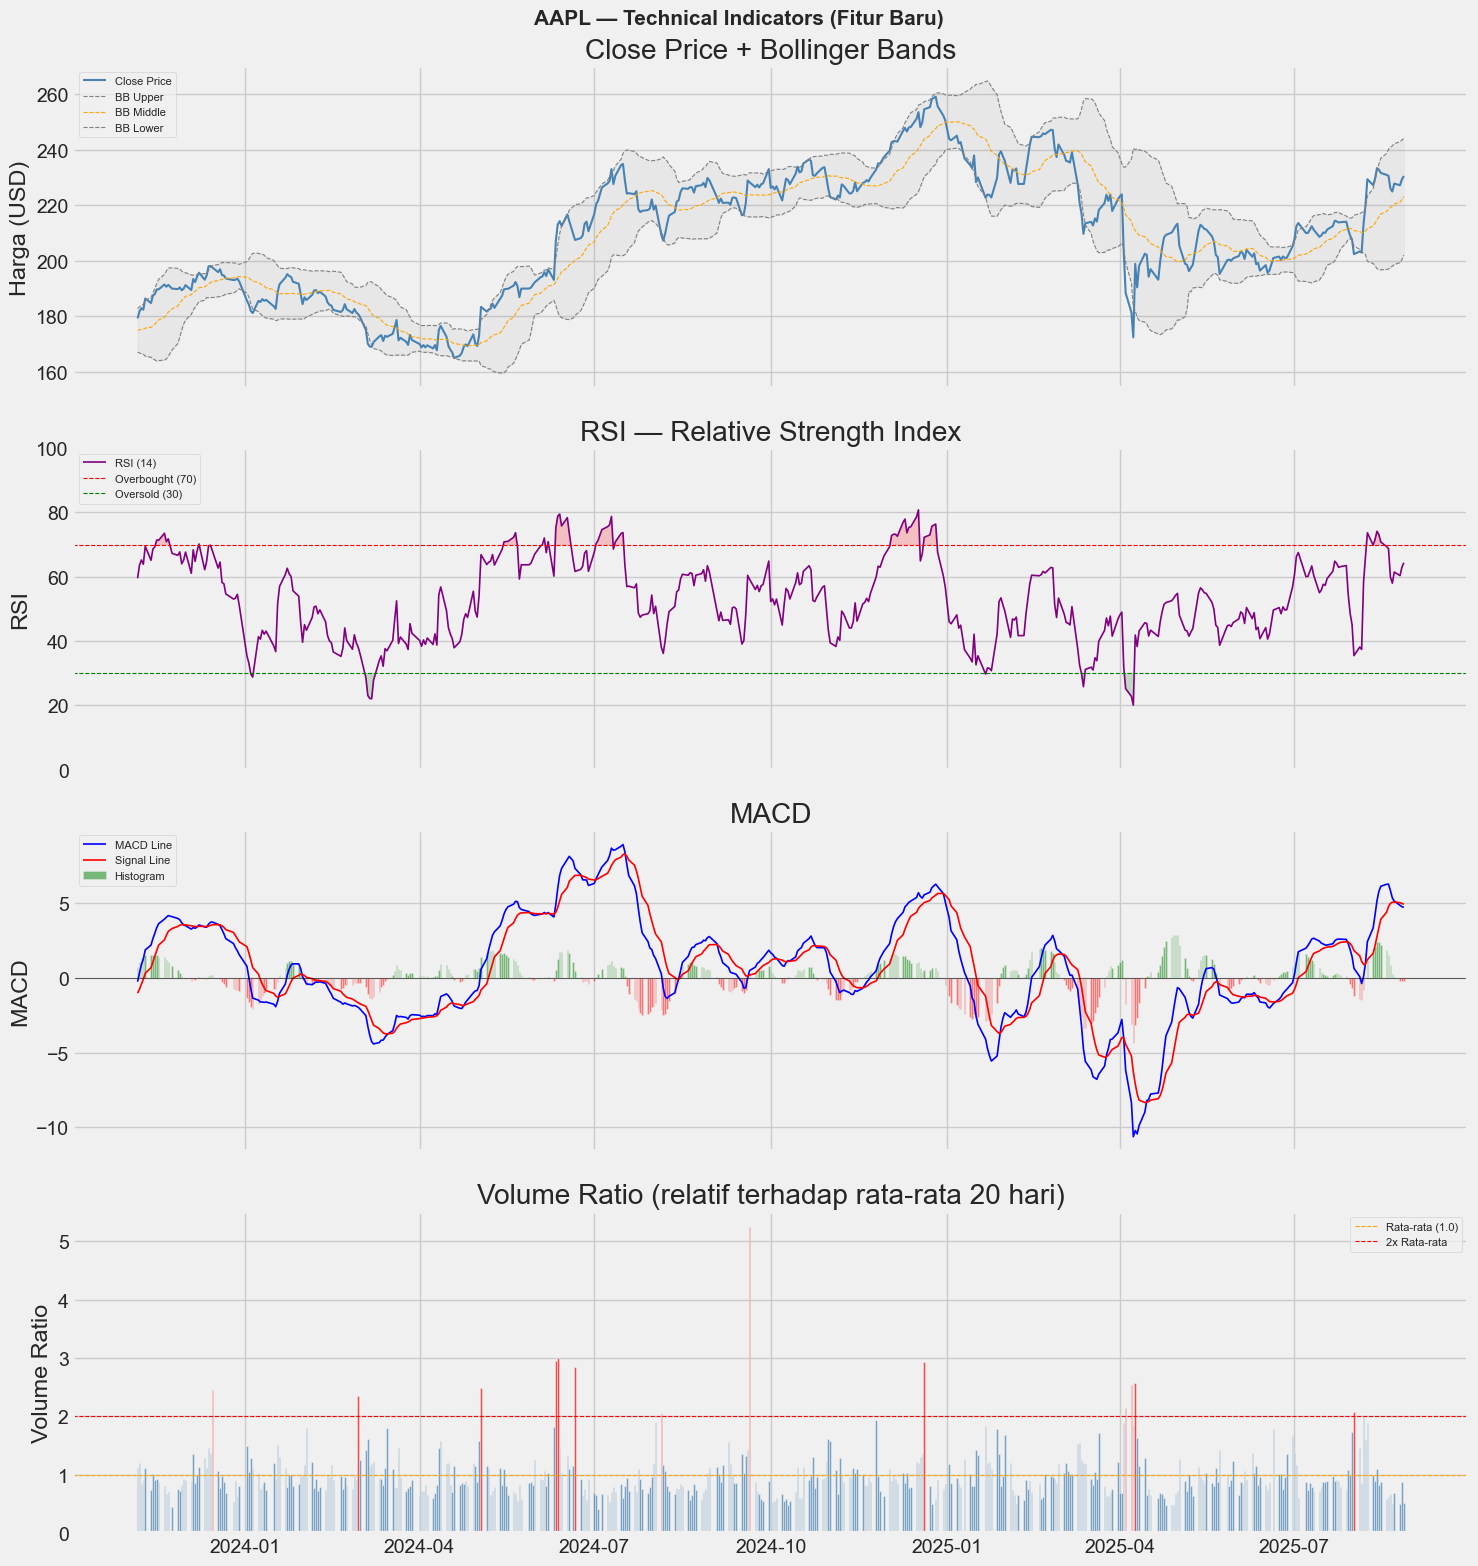

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)
fig.suptitle('AAPL — Technical Indicators (Fitur Baru)', fontsize=15, fontweight='bold')

# Plot 1: Harga + Bollinger Bands
axes[0].plot(aapl['Close'], label='Close Price', color='steelblue', linewidth=1.5)
axes[0].plot(aapl['BB_Upper'],  label='BB Upper',  color='gray', linewidth=0.8, linestyle='--')
axes[0].plot(aapl['BB_Middle'], label='BB Middle', color='orange', linewidth=0.8, linestyle='--')
axes[0].plot(aapl['BB_Lower'],  label='BB Lower',  color='gray', linewidth=0.8, linestyle='--')
axes[0].fill_between(aapl.index, aapl['BB_Upper'], aapl['BB_Lower'], alpha=0.08, color='gray')
axes[0].set_ylabel('Harga (USD)')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title('Close Price + Bollinger Bands')

# Plot 2: RSI
# Kamu bisa lihat kapan AAPL overbought (RSI > 70) atau oversold (RSI < 30)
axes[1].plot(aapl['RSI'], label='RSI (14)', color='purple', linewidth=1.2)
axes[1].axhline(y=70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].fill_between(aapl.index, aapl['RSI'], 70, where=(aapl['RSI'] >= 70), alpha=0.2, color='red')
axes[1].fill_between(aapl.index, aapl['RSI'], 30, where=(aapl['RSI'] <= 30), alpha=0.2, color='green')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_title('RSI — Relative Strength Index')

# Plot 3: MACD
# Histogram hijau = bullish momentum, merah = bearish momentum
axes[2].plot(aapl['MACD'],        label='MACD Line',   color='blue', linewidth=1.2)
axes[2].plot(aapl['MACD_Signal'], label='Signal Line', color='red',  linewidth=1.2)
axes[2].bar(aapl.index, aapl['MACD_Hist'],
            color=['green' if v >= 0 else 'red' for v in aapl['MACD_Hist']],
            alpha=0.5, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.4)
axes[2].set_ylabel('MACD')
axes[2].legend(loc='upper left', fontsize=8)
axes[2].set_title('MACD')

# Plot 4: Volume Ratio
# Batang merah = volume 2x lipat rata-rata → biasanya momen penting
axes[3].bar(aapl.index, aapl['Volume_Ratio'],
            color=['red' if v >= 2 else 'steelblue' for v in aapl['Volume_Ratio']],
            alpha=0.7)
axes[3].axhline(y=1, color='orange', linestyle='--', linewidth=0.8, label='Rata-rata (1.0)')
axes[3].axhline(y=2, color='red',    linestyle='--', linewidth=0.8, label='2x Rata-rata')
axes[3].set_ylabel('Volume Ratio')
axes[3].legend(loc='upper right', fontsize=8)
axes[3].set_title('Volume Ratio (relatif terhadap rata-rata 20 hari)')

plt.tight_layout()
plt.show()

---
## Bagian 4 — Preprocessing: Scaling semua fitur

Di kode kamu sebelumnya:
```python
# kode lama — scale hanya 1 kolom
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)  # dataset hanya berisi Close
```

Sekarang kita scale **semua fitur sekaligus**, tapi dengan aturan penting:

> ⚠️ **Data Leakage** — scaler hanya boleh di-fit di data training, BUKAN di data test.
> Kalau scaler di-fit di semua data (termasuk test), artinya model sudah 'mengintip' masa depan
> saat training. Hasil evaluasinya jadi tidak valid — terlalu optimis.
>
> Di kode kamu yang lama, `scaler.fit_transform(dataset)` di-fit ke semua data (termasuk test).
> Ini yang kita perbaiki sekarang.

In [5]:
# Fitur yang akan dipakai model sebagai input
# Kita mulai dengan 10 fitur ini (dari 1 fitur sebelumnya)
FEATURES = [
    'Close',        # harga penutupan — target yang diprediksi
    'Volume',       # volume trading
    'RSI',          # momentum oscillator
    'MACD',         # trend momentum
    'MACD_Signal',  # signal line MACD
    'BB_Width',     # lebar Bollinger Band (volatilitas)
    'SMA_20',       # tren jangka pendek
    'SMA_50',       # tren jangka menengah
    'Volume_Ratio', # volume relatif
    'Daily_Return', # persentase perubahan harian
]

# Ambil datanya
data = aapl[FEATURES].values  # shape: (n_hari, 10 fitur)

# Split: 95% training, 5% testing
# Kita pakai 95/5 supaya sama seperti kode kamu (.95)
# PENTING: tidak di-shuffle! Urutan waktu harus dijaga
training_data_len = int(np.ceil(len(data) * 0.95))

train_data = data[:training_data_len]
test_data  = data[training_data_len:]

print(f'Total data        : {len(data)} hari')
print(f'Training data     : {len(train_data)} hari ({training_data_len/len(data)*100:.0f}%)')
print(f'Test data         : {len(test_data)} hari ({len(test_data)/len(data)*100:.0f}%)')

# Fit scaler HANYA di training data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)  # fit + transform
test_scaled  = scaler.transform(test_data)       # hanya transform (tidak fit lagi)

# Kita butuh scaler terpisah khusus untuk kolom Close saja
# supaya nanti kita bisa inverse_transform hanya prediksinya
# (prediksi hanya 1 angka: Close price, bukan semua 10 fitur)
close_col_idx = FEATURES.index('Close')  # posisi kolom Close di array
scaler_close = MinMaxScaler(feature_range=(0, 1))
scaler_close.fit(train_data[:, close_col_idx].reshape(-1, 1))

print(f'\nScaling selesai. Range setelah scaling: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')
print(f'Posisi kolom Close di array fitur: index {close_col_idx}')

Total data        : 453 hari
Training data     : 431 hari (95%)
Test data         : 22 hari (5%)

Scaling selesai. Range setelah scaling: [0.000, 1.000]
Posisi kolom Close di array fitur: index 0


---
## Bagian 5 — Buat sequences (sliding window)

Di kode kamu sebelumnya:
```python
# kode lama — hanya 1 fitur
x_train.append(train_data[i-60:i, 0])  # kolom ke-0 saja (Close)
y_train.append(train_data[i, 0])
```

Sekarang kita ambil **semua kolom** (bukan hanya kolom ke-0):
```python
x_train.append(train_data[i-60:i, :])  # semua kolom
```

Cara kerja sliding window:
```
Hari 1-60   → prediksi hari ke-61
Hari 2-61   → prediksi hari ke-62
Hari 3-62   → prediksi hari ke-63
... dst
```

In [6]:
SEQUENCE_LENGTH = 60  # sama seperti kode kamu sebelumnya

# --- Buat x_train dan y_train ---
x_train = []
y_train = []

for i in range(SEQUENCE_LENGTH, len(train_scaled)):
    # x: 60 hari sebelumnya, SEMUA fitur (bukan cuma Close)
    x_train.append(train_scaled[i - SEQUENCE_LENGTH:i, :])  # shape per item: (60, 10)
    # y: harga Close hari ini (kolom ke-0)
    y_train.append(train_scaled[i, close_col_idx])

x_train = np.array(x_train)  # shape: (n_samples, 60, 10)
y_train = np.array(y_train)  # shape: (n_samples,)

# --- Buat x_test dan y_test ---
# Persis sama logikanya dengan kode kamu:
# test_data dimulai dari training_data_len - 60
# supaya kita punya 60 hari sebelumnya sebagai context untuk prediksi pertama
test_data_full = np.vstack([train_scaled[-SEQUENCE_LENGTH:], test_scaled])

x_test = []
y_test = data[training_data_len:, close_col_idx]  # harga Close asli (belum discale)

for i in range(SEQUENCE_LENGTH, len(test_data_full)):
    x_test.append(test_data_full[i - SEQUENCE_LENGTH:i, :])

x_test = np.array(x_test)  # shape: (n_samples, 60, 10)

print(f'Shape x_train : {x_train.shape}  ← (jumlah sample, sequence, fitur)')
print(f'Shape y_train : {y_train.shape}')
print(f'Shape x_test  : {x_test.shape}')
print(f'\nSebelumnya x_train shape: (n, 60, 1) — sekarang (n, 60, {x_train.shape[2]})')
print(f'Model sekarang punya {x_train.shape[2]}x lebih banyak informasi!')

Shape x_train : (371, 60, 10)  ← (jumlah sample, sequence, fitur)
Shape y_train : (371,)
Shape x_test  : (22, 60, 10)

Sebelumnya x_train shape: (n, 60, 1) — sekarang (n, 60, 10)
Model sekarang punya 10x lebih banyak informasi!


---
## Bagian 6 — Build model LSTM (versi upgrade)

Kode kamu sebelumnya:
```python
# kode lama
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))  # 1 fitur
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.fit(x_train, y_train, batch_size=1, epochs=1)  # hanya 1 epoch!
```

Ada dua masalah di sini:
1. `input_shape=(x_train.shape[1], 1)` — angka `1` ini harus diganti ke jumlah fitur kita
2. `batch_size=1, epochs=1` — 1 epoch itu sangat sedikit, model belum sempat belajar banyak

Yang kita tambahkan:
- **Dropout** — mencegah model 'hafal' data training (overfitting)
- **EarlyStopping** — berhenti otomatis kalau sudah tidak ada improvement
- **Epochs lebih banyak** — kasih model waktu untuk belajar lebih

In [7]:
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

n_features = x_train.shape[2]  # = 10, otomatis dari data

# Build model
# Arsitektur sama seperti kode kamu: LSTM(128) → LSTM(64) → Dense(25) → Dense(1)
# Yang beda: input_shape sekarang (60, 10) bukan (60, 1)
# dan kita tambahkan Dropout setelah setiap LSTM layer
model = Sequential([
    # Layer 1: LSTM dengan 128 units
    # return_sequences=True → output diteruskan ke LSTM berikutnya (bukan ke Dense)
    # input_shape → (60 hari, 10 fitur)
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, n_features)),

    # Dropout: saat training, 20% neuron dimatikan secara acak
    # Ini memaksa model belajar pola yang lebih umum, bukan hafal data
    Dropout(0.2),

    # Layer 2: LSTM dengan 64 units
    # return_sequences=False → hanya output terakhir yang diteruskan ke Dense
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Dense layers — sama seperti kode kamu
    Dense(25),
    Dense(1)   # output: 1 angka = prediksi Close price besok
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

print(f'\nTotal parameters: {model.count_params():,}')
print(f'Input shape model: (batch, {SEQUENCE_LENGTH}, {n_features})')

d:\.vscode\kodingan\stock-prediction-project\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,227 (477.45 KB)

 Trainable params: 122,227 (477.45 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 122,227
Input shape model: (batch, 60, 10)


---
## Bagian 7 — Training

Di kode lama kamu `epochs=1` — itu artinya model baru lihat data satu kali saja. Itu terlalu sedikit.

Analogi: bayangkan kamu belajar matematika tapi hanya baca buku satu kali tanpa latihan soal. Hasilnya pasti kurang optimal.

Sekarang kita pakai `EarlyStopping` — model akan terus belajar sampai nilainya tidak membaik lagi, lalu berhenti sendiri.

In [8]:
# EarlyStopping: berhenti training kalau val_loss tidak membaik setelah 10 epoch
# restore_best_weights=True → pakai weights terbaik, bukan weights terakhir
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train, y_train,
    batch_size=32,     # lebih efisien dari batch_size=1
    epochs=50,         # maksimal 50, tapi EarlyStopping bisa berhenti lebih awal
    validation_split=0.1,  # 10% dari training jadi validation
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTraining selesai di epoch: {len(history.history["loss"])}')
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 289ms/step - loss: 0.0753 - val_loss: 0.0076
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - loss: 0.0201 - val_loss: 0.0025
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0155 - val_loss: 0.0035
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0119 - val_loss: 0.0015
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0108 - val_loss: 0.0022
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0122 - val_loss: 0.0015
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0107 - val_loss: 0.0015
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 0.0084 - val_loss: 0.0014
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0091 - val_loss: 0.0015
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0080 - val_loss: 0.0016
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0089 - val_loss: 0.0027
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/ste

---
## Bagian 8 — Visualisasi training loss

Grafik ini penting untuk cek apakah model overfitting atau tidak.

- **Bagus**: training loss dan val_loss turun bersama-sama
- **Overfitting**: training loss terus turun tapi val_loss mulai naik

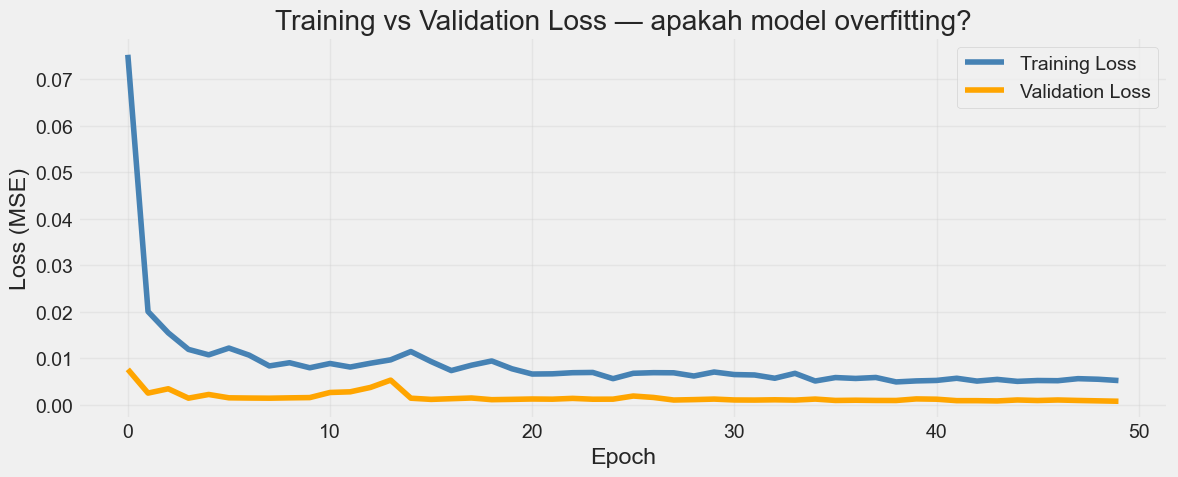

✅ Model terlihat sehat — val_loss tidak jauh dari training loss.


In [9]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss — apakah model overfitting?')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretasi otomatis
final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
ratio = final_val / final_train

if ratio < 1.5:
    print('✅ Model terlihat sehat — val_loss tidak jauh dari training loss.')
elif ratio < 3:
    print('⚠️  Ada sedikit overfitting. Coba naikkan Dropout atau kurangi epochs.')
else:
    print('❌ Overfitting cukup parah. Coba tambah lebih banyak data atau naikkan Dropout.')

---
## Bagian 9 — Evaluasi dan perbandingan dengan model lama

Di kode kamu sebelumnya:
```python
# kode lama
predictions = scaler.inverse_transform(predictions)  
# ini bisa langsung karena scaler dulu hanya 1 fitur
```

Sekarang scaler kita punya 10 fitur, jadi kita pakai `scaler_close` yang khusus untuk Close saja.

In [10]:
# Prediksi
predictions_scaled = model.predict(x_test)

# Inverse transform: kembalikan dari skala 0-1 ke harga USD asli
# Pakai scaler_close (bukan scaler) karena output model hanya 1 kolom (Close)
predictions = scaler_close.inverse_transform(predictions_scaled)

# y_test sudah dalam harga asli (kita simpan tadi sebelum scaling)
y_test_prices = y_test.reshape(-1, 1)

# Hitung metrik
rmse = np.sqrt(mean_squared_error(y_test_prices, predictions))
mape = np.mean(np.abs((y_test_prices - predictions) / y_test_prices)) * 100

print('=' * 50)
print('EVALUASI MODEL UPGRADE vs MODEL LAMA')
print('=' * 50)
print(f'RMSE model baru  : ${rmse:.4f}')
print(f'MAPE model baru  : {mape:.4f}%')
print()
print('Hasil model lama kamu (dari notebook sebelumnya):')
print(f'  RMSE model lama : $5.7052')
print(f'  MAPE model lama : 2.4546%')
print('=' * 50)
if mape < 2.4546:
    print(f'✅ Model baru lebih akurat! MAPE turun {2.4546 - mape:.4f}%')
else:
    print(f'⚠️  Model lama masih lebih baik di data ini. Coba tuning lebih lanjut.')
    print(f'   (Ini normal — feature engineering tidak selalu langsung improve semuanya)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
EVALUASI MODEL UPGRADE vs MODEL LAMA
RMSE model baru  : $7.8193
MAPE model baru  : 2.7893%

Hasil model lama kamu (dari notebook sebelumnya):
  RMSE model lama : $5.7052
  MAPE model lama : 2.4546%
⚠️  Model lama masih lebih baik di data ini. Coba tuning lebih lanjut.
   (Ini normal — feature engineering tidak selalu langsung improve semuanya)


---
## Bagian 10 — Plot prediksi vs aktual

Ini versi upgrade dari plot di kode kamu sebelumnya.

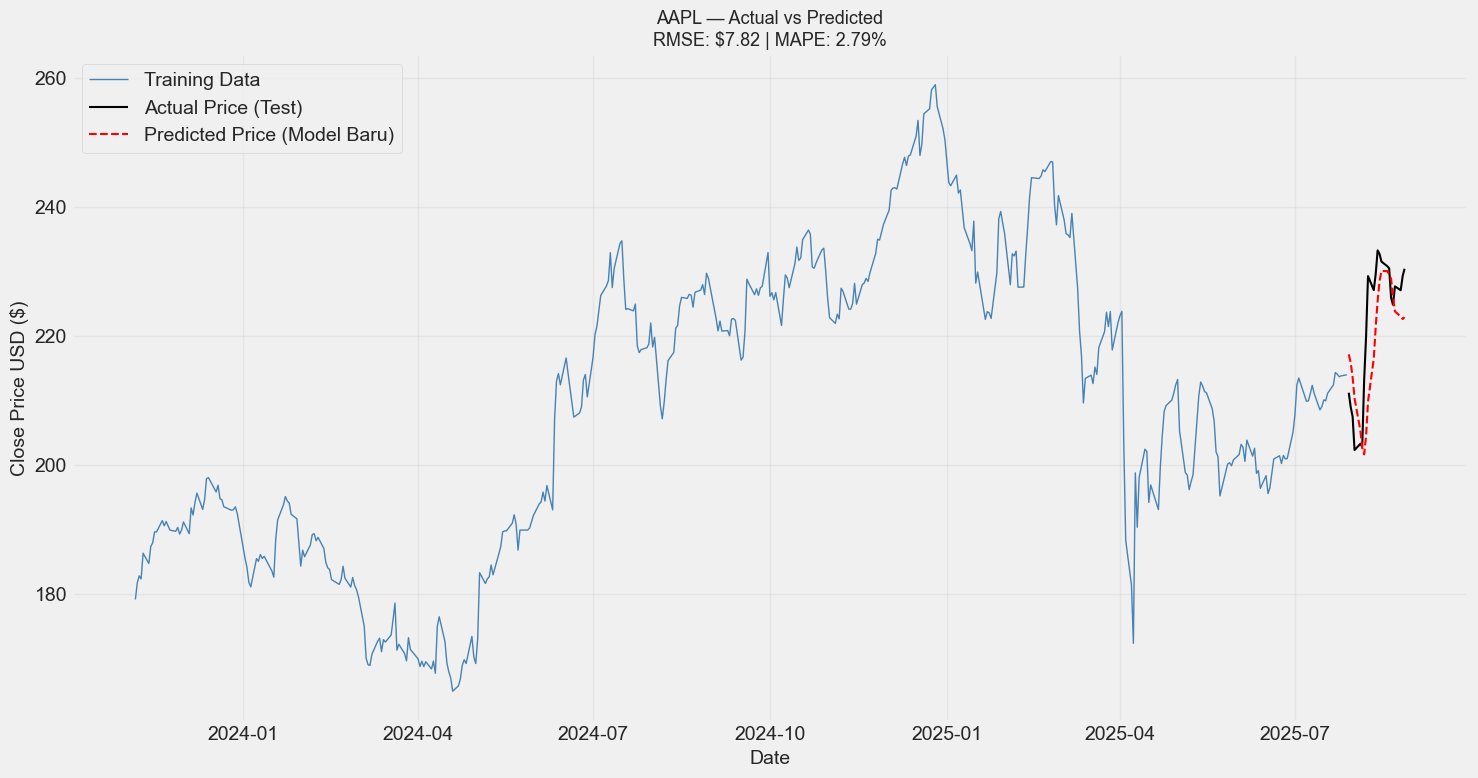

In [11]:
# Ambil data untuk plot — sama seperti logika kode kamu
train_plot = aapl['Close'][:training_data_len]
test_dates = aapl.index[training_data_len:]

plt.figure(figsize=(15, 8))
plt.title(f'AAPL — Actual vs Predicted\nRMSE: ${rmse:.2f} | MAPE: {mape:.2f}%', fontsize=13)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price USD ($)', fontsize=14)

# Data training (biru)
plt.plot(train_plot.index, train_plot.values, label='Training Data', color='steelblue', linewidth=1)

# Harga aktual di periode test (hitam)
plt.plot(test_dates, y_test_prices, label='Actual Price (Test)', color='black', linewidth=1.5)

# Prediksi model baru (merah)
plt.plot(test_dates, predictions, label='Predicted Price (Model Baru)', 
         color='red', linewidth=1.5, linestyle='--')

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bagian 11 — Prediksi masa depan (sama seperti kode kamu)

Di kode kamu sebelumnya, prediksi 2 hari ke depan pakai `last_60_days` dari `pred_dfs` (hanya Close).

Sekarang kita butuh 60 hari terakhir dari **semua 10 fitur**, bukan hanya Close.

In [12]:
# Ambil 60 hari terakhir dari semua fitur (sudah discale)
last_60_days_all = scaler.transform(aapl[FEATURES].values[-SEQUENCE_LENGTH:])

# Untuk prediksi multi-step, kita perlu update semua fitur
# Tapi karena kita hanya prediksi Close, kita update Close saja
# dan hold fitur lain tetap (pendekatan sederhana yang cukup valid untuk 1-2 hari)
temp_input = last_60_days_all.copy().tolist()  # list of lists, shape (60, 10)

future_predictions = []
future_dates = [datetime(2025, 8, 28), datetime(2025, 8, 29)]

for i in range(len(future_dates)):
    # Ambil 60 step terakhir, reshape jadi (1, 60, 10)
    X_future = np.array(temp_input[-SEQUENCE_LENGTH:]).reshape(1, SEQUENCE_LENGTH, n_features)

    # Prediksi
    pred_scaled = model.predict(X_future, verbose=0)
    pred_price  = scaler_close.inverse_transform(pred_scaled)[0][0]

    future_predictions.append(pred_price)

    # Update window: tambahkan baris baru dengan nilai prediksi di kolom Close,
    # dan copy nilai fitur lain dari baris terakhir
    new_row = temp_input[-1].copy()
    new_row[close_col_idx] = pred_scaled[0][0]  # update hanya Close yang sudah discale
    temp_input.append(new_row)

# Tampilkan hasil
print('Prediksi harga AAPL:')
for d, p in zip(future_dates, future_predictions):
    print(f'  {d.strftime("%d %B %Y")}: ${p:.4f}')

# Untuk referensi — harga aktual yang sudah kamu catat sebelumnya
actual = [232.56, 232.14]
y_true_future = np.array(actual)
y_pred_future = np.array(future_predictions)

rmse_future = np.sqrt(mean_squared_error(y_true_future, y_pred_future))
mape_future = np.mean(np.abs((y_true_future - y_pred_future) / y_true_future)) * 100

print(f'\nHarga aktual  : {actual}')
print(f'RMSE          : {rmse_future:.4f}')
print(f'MAPE          : {mape_future:.4f}%')

print(f'\nBandingkan dengan model lama:')
print(f'  RMSE lama: 5.7052 | RMSE baru: {rmse_future:.4f}')
print(f'  MAPE lama: 2.4546% | MAPE baru: {mape_future:.4f}%')

Prediksi harga AAPL:
  28 August 2025: $224.1756
  29 August 2025: $224.9057

Harga aktual  : [232.56, 232.14]
RMSE          : 7.8305
MAPE          : 3.3608%

Bandingkan dengan model lama:
  RMSE lama: 5.7052 | RMSE baru: 7.8305
  MAPE lama: 2.4546% | MAPE baru: 3.3608%


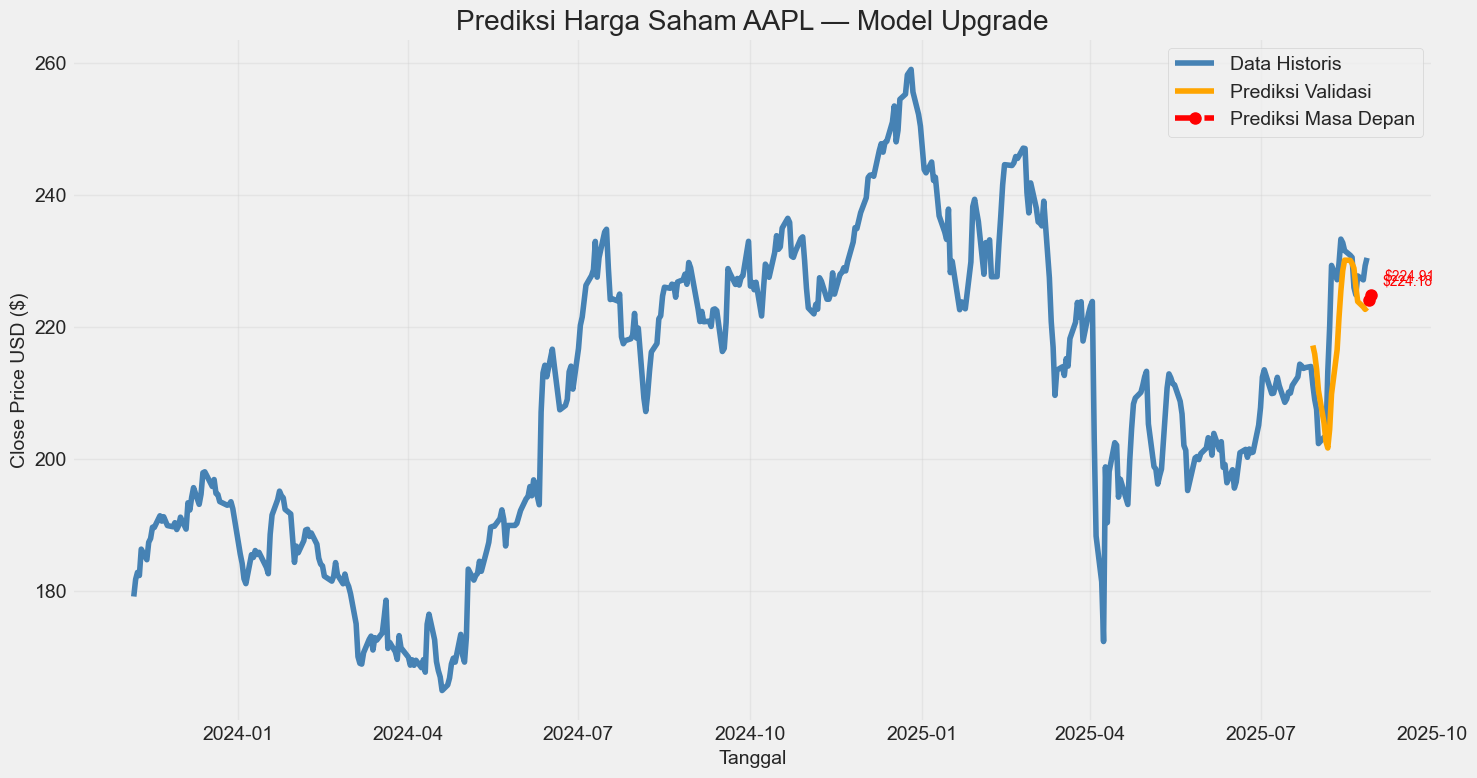

In [13]:
# Plot final — sama seperti kode kamu, versi upgrade
plt.figure(figsize=(15, 8))
plt.title('Prediksi Harga Saham AAPL — Model Upgrade')
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Close Price USD ($)', fontsize=14)

plt.plot(aapl['Close'], label='Data Historis', color='steelblue')
plt.plot(test_dates, predictions, label='Prediksi Validasi', color='orange')
plt.plot(future_dates, future_predictions, 'ro--', markersize=8, label='Prediksi Masa Depan')

# Label harga di titik prediksi
for d, p in zip(future_dates, future_predictions):
    plt.annotate(f'${p:.2f}', xy=(d, p), xytext=(10, 10),
                 textcoords='offset points', fontsize=10, color='red')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Bagian 12 — Simpan model upgrade

Kita simpan model baru dengan nama berbeda supaya model lama tidak tertimpa.

In [14]:
import joblib, json

os.makedirs('../models', exist_ok=True)

# Simpan model — nama berbeda dari yang lama ('v2' vs original)
model.save('../models/AAPLstock_price_prediction_model_v2.keras')
print('Model tersimpan: ../models/AAPLstock_price_prediction_model_v2.keras')

# Simpan scaler — kita butuh ini untuk prediksi di masa depan
joblib.dump(scaler,       '../models/scaler_all_features.pkl')
joblib.dump(scaler_close, '../models/scaler_close.pkl')
print('Scaler tersimpan.')

# Simpan daftar fitur — WAJIB disimpan!
# Kalau nanti load model, urutan fitur harus persis sama
meta = {'features': FEATURES, 'sequence_length': SEQUENCE_LENGTH}
with open('../models/model_v2_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Meta tersimpan: ../models/model_v2_meta.json')

Model tersimpan: ../models/AAPLstock_price_prediction_model_v2.keras
Scaler tersimpan.
Meta tersimpan: ../models/model_v2_meta.json


---
## Ringkasan: Apa yang berubah dari model lama ke model baru?

| Aspek | Model Lama (v1) | Model Baru (v2) |
|-------|----------------|----------------|
| Jumlah fitur input | 1 (Close saja) | 10 (Close + RSI + MACD + BB + Volume + ...) |
| Input shape | `(60, 1)` | `(60, 10)` |
| Dropout | ❌ Tidak ada | ✅ 0.2 setelah tiap LSTM |
| Epochs | 1 epoch saja | Sampai 50, stop otomatis |
| Batch size | 1 (lambat) | 32 (lebih efisien) |
| Data leakage | ⚠️ scaler di-fit ke semua data | ✅ scaler hanya di-fit di training |
| Evaluasi | RMSE + MAPE di 2 hari | RMSE + MAPE di seluruh test set |

## Next step: Phase 1b

Setelah ini kita akan eksperimen dengan:
- Berbagai sequence length (30, 60, 90 hari)
- Berbagai jumlah LSTM units
- Membandingkan hasilnya secara sistematis

**Catat RMSE dan MAPE dari run ini** sebagai baseline baru!